In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import os
import random
import torch
import torchvision 
import torchvision.transforms as T
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from GAN import GANTrainer, Generator, Discriminator

In [3]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def show_images(images):
    images = torch.reshape(
        images, [images.shape[0], -1]
    )  # images reshape to (batch_size, D)
    sqrtn = int(math.ceil(math.sqrt(images.shape[0])))
    sqrtimg = int(math.ceil(math.sqrt(images.shape[1])))

    fig = plt.figure(figsize=(sqrtn, sqrtn))
    gs = gridspec.GridSpec(sqrtn, sqrtn)
    gs.update(wspace=0.05, hspace=0.05)

    for i, img in enumerate(images):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect("equal")
        plt.imshow(img.reshape([sqrtimg, sqrtimg]))
    return

download MNIST if not exist


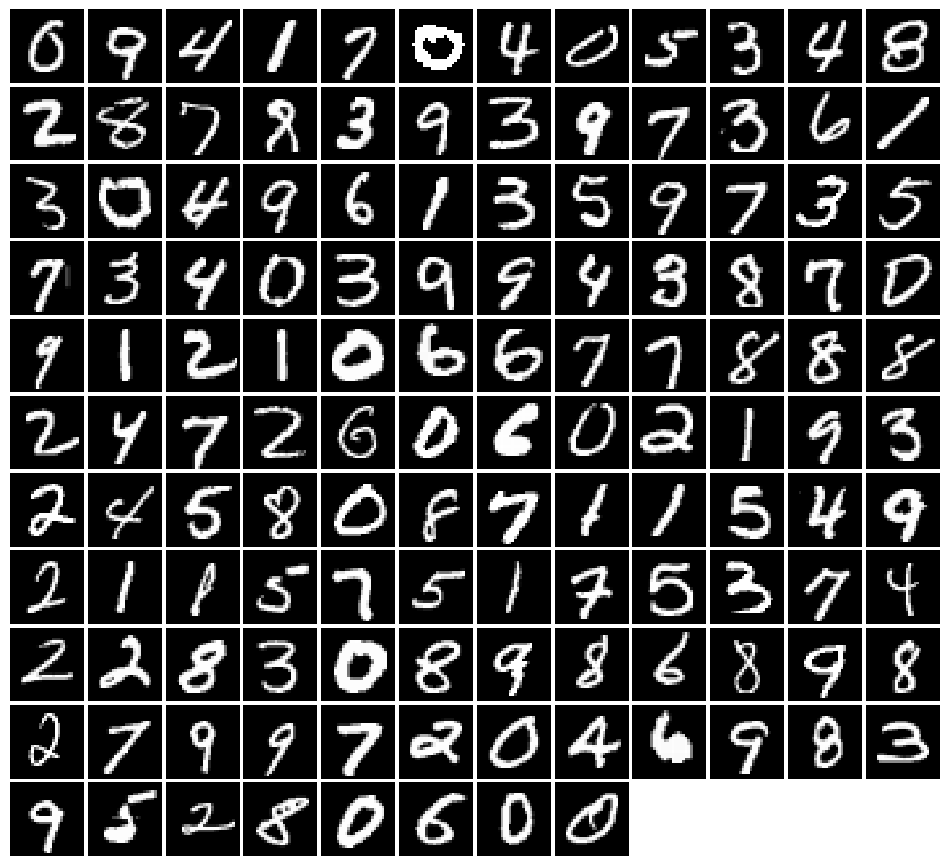

In [4]:
# MINST

batch_size = 128
NOISE_DIM = 96

print('download MNIST if not exist')

mnist_train = torchvision.datasets.MNIST('../../Data/MNIST', train=True, download=True, transform=T.ToTensor())
loader_train = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)

imgs = next(iter(loader_train))[0].view(batch_size, 784)
show_images(imgs)

In [6]:
# seed

random.seed(0)
torch.manual_seed(0)

dtype = torch.float
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

model_save_root = "../../Models/GAN"
os.makedirs(model_save_root)

# GAN

### Train

In [7]:
generator = Generator(NOISE_DIM)
discriminator = Discriminator()

trainer = GANTrainer(
    generator=generator,
    discriminator=discriminator,
    noise_dim=NOISE_DIM,
    dtype=dtype,
    device=device
)

trainer.train(train_dataloader=loader_train, 
              num_epochs=10, 
              log_interval=250)

torch.save(trainer.generator.state_dict(), os.path.join(model_save_root,'Generator.pth'))
torch.save(trainer.discriminator.state_dict(), os.path.join(model_save_root,'Discriminator.pth'))

Iter: 0, D: 1.365, G:0.7197
Iter: 250, D: 1.389, G:0.6558
Iter: 500, D: 1.256, G:1.594
Iter: 750, D: 1.141, G:1.76
Iter: 1000, D: 1.294, G:0.8201
Iter: 1250, D: 1.113, G:1.255
Iter: 1500, D: 1.418, G:0.8452
Iter: 1750, D: 1.294, G:0.7643
Iter: 2000, D: 1.346, G:0.8498
Iter: 2250, D: 1.257, G:0.8156
Iter: 2500, D: 1.256, G:0.8574
Iter: 2750, D: 1.281, G:0.7604
Iter: 3000, D: 1.36, G:0.6989
Iter: 3250, D: 1.375, G:0.8643
Iter: 3500, D: 1.36, G:0.8406
Iter: 3750, D: 1.314, G:0.9159
Iter: 4000, D: 1.369, G:0.7797
Iter: 4250, D: 1.286, G:0.8224
Iter: 4500, D: 1.336, G:0.7672


### Visualization

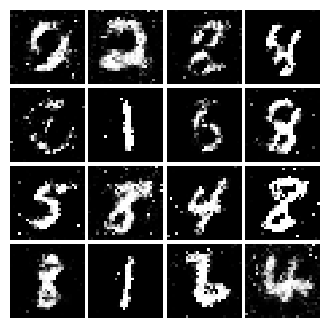

In [8]:
G = Generator(NOISE_DIM).to(device)
G.load_state_dict(torch.load('../../Models/GAN/Generator.pth', map_location=device))
G.eval()

num_samples = 16
with torch.no_grad():
    z = 2 * torch.rand(num_samples, NOISE_DIM, device=device) - 1
    fake_images = G(z)                  # [-1, 1]
    fake_images = (fake_images + 1) / 2 # [0, 1] 

show_images(fake_images.cpu())